# V44: Stable Graph vs Static Markowitz with Excel Export (LQ45)

Notebook ini adalah versi lanjutan dari V43 yang menambahkan fitur ekspor data ke Excel. 
Fitur Utama:
1. **Stable Graph Lookback (60 Days)** untuk pemilihan aset yang lebih konsisten.
2. **Static Markowitz Baseline** (Optimasi sekali di akhir training).
3. **Excel Export**: Menyimpan hasil perbandingan portfolio value harian ke dalam file `v19_portfolio_backtest_2025.xlsx`.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import fbeta_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

print(f"✓ Data Loaded: {len(data)} rows")

✓ Data Loaded: 712 rows


In [2]:
# --- 2. AI Training (SMA Crossover Target) ---
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]
X_test = features.loc[features.index.year == 2025]

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

train_probs = xgb_model.predict_proba(X_train)[:, 1]
opt_t = np.linspace(0.3, 0.7, 41)[np.argmax([fbeta_score(y_train, (train_probs >= t).astype(int), beta=0.5) for t in np.linspace(0.3, 0.7, 41)])]
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)

print(f"Optimized Threshold: {opt_t:.2f}")

Optimized Threshold: 0.54


In [3]:
# --- 3. Core Logic with 60D Lookback ---

def get_mis_assets(returns_window, correlation_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = returns_window.columns
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.iloc[i, j]) > correlation_threshold:
                G.add_edge(assets[i], assets[j])
    return list(nx.approximation.maximum_independent_set(G))

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    res = minimize(lambda w: -np.sum(w * mu) / np.sqrt(np.dot(w.T, np.dot(sigma, w))) if np.dot(w.T, np.dot(sigma, w)) > 0.0001 else 0,
                   [1./len(mu)]*len(mu), method='SLSQP', 
                   bounds=tuple((0, 1) for _ in range(len(mu))), 
                   constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def run_simulation(test_dates, returns, ai_probs, threshold, is_static=False, static_weights=None, fee=0.0025, g_lookback=60):
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    prev_weights = {}
    risk_status = False
    buffer = 0.05
    
    for i, date in enumerate(test_dates[:-1]):
        if is_static:
            weights = static_weights
        else:
            prob = ai_probs.loc[date]
            if not risk_status and prob > (threshold + buffer): risk_status = True
            elif risk_status and prob < (threshold - buffer): risk_status = False
            
            if not risk_status:
                weights = {'CASH': 1.0}
            else:
                loc_idx = returns.index.get_loc(date)
                window_rets = returns.iloc[loc_idx-g_lookback:loc_idx]
                selected = get_mis_assets(window_rets)
                weights = optimize_markowitz(window_rets[selected])
        
        # Fees
        all_assets = set(list(weights.keys()) + list(prev_weights.keys()))
        turnover = sum(abs(weights.get(a, 0) - prev_weights.get(a, 0)) for a in all_assets)
        val -= val * turnover * fee
        
        # Return
        next_date = test_dates[i+1]
        day_ret = 0 if 'CASH' in weights else sum(w * returns.loc[next_date, a] for a, w in weights.items())
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        prev_weights = weights
        
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

✓ Results exported to v19_portfolio_backtest_2025.xlsx


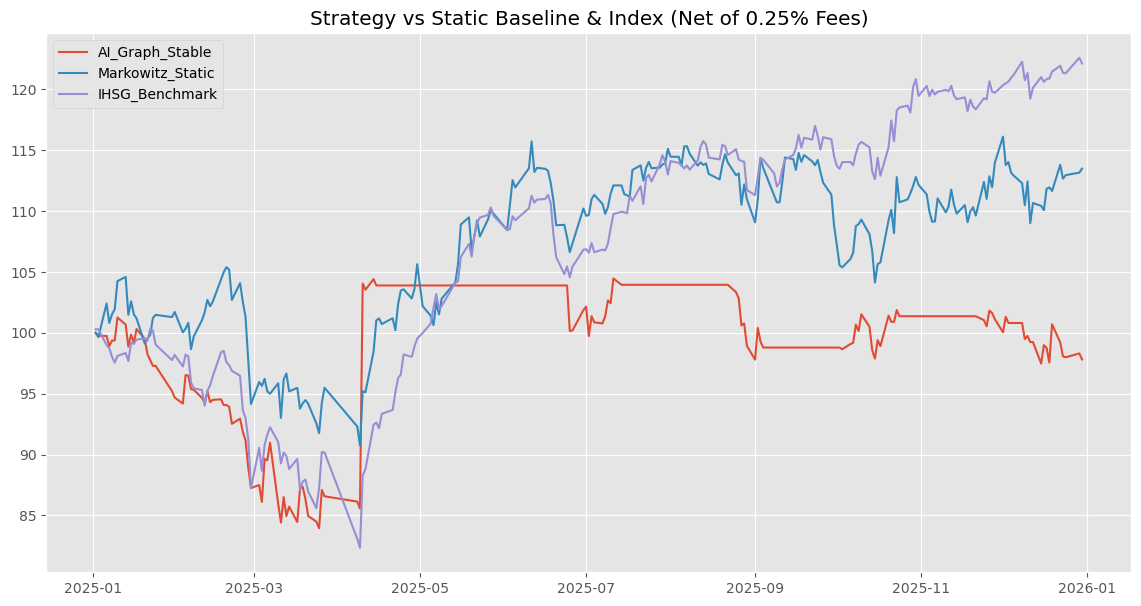

In [4]:
# --- 4. Static Markowitz Setup ---
last_train_idx = returns.index.get_loc(X_train.index[-1])
static_window = returns.iloc[last_train_idx-60:last_train_idx]
static_weights = optimize_markowitz(static_window)

# --- 5. Backtest ---
test_dates = test_probs.index
fee = 0.0025

results = {}
results['AI_Graph_Stable'] = run_simulation(test_dates, returns, test_probs, opt_t, fee=fee, g_lookback=60)
results['Markowitz_Static'] = run_simulation(test_dates, returns, None, None, is_static=True, static_weights=static_weights, fee=fee)
results['IHSG_Benchmark'] = pd.DataFrame({'Portfolio_Value': (market_return.loc[test_dates].cumsum().apply(np.exp) * 100)}, index=test_dates)

# --- 6. Export to Excel ---
export_df = pd.DataFrame(index=test_dates)
for label, df in results.items():
    export_df[label] = df['Portfolio_Value']

export_file = 'v19_portfolio_backtest_2025.xlsx'
export_df.to_excel(export_file)
print(f"✓ Results exported to {export_file}")

# --- 7. Plot Results ---
plt.figure(figsize=(14, 7))
for label, df in results.items():
    plt.plot(df.index, df['Portfolio_Value'], label=label)

plt.title(f"Strategy vs Static Baseline & Index (Net of {fee*100}% Fees)")
plt.legend()
plt.show()